In [3]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

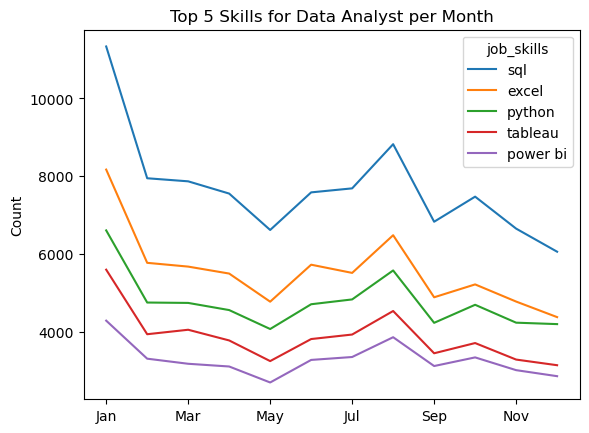

In [18]:
# create new column for month number 
df_da['job_posted_month_no'] = df_da['job_posted_date'].dt.month

# explode the job skills column and pivot 
df_da_explode = df_da.explode('job_skills')
df_da_pivot = df_da_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

# sort the skills by count 
df_da_pivot.loc['Total'] = df_da_pivot.sum()
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending=False).index]
df_da_pivot = df_da_pivot.drop('Total') 

# use month fro plotting 
df_da_pivot = df_da_pivot.reset_index()
df_da_pivot['job_posted_month'] = df_da_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b') )
df_da_pivot = df_da_pivot.set_index('job_posted_month')
df_da_pivot = df_da_pivot.drop(columns='job_posted_month_no')


# get the top 5 skills 
df_da_pivot.iloc[: , :5].plot(kind='line')
plt.title('Top 5 Skills for Data Analyst per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

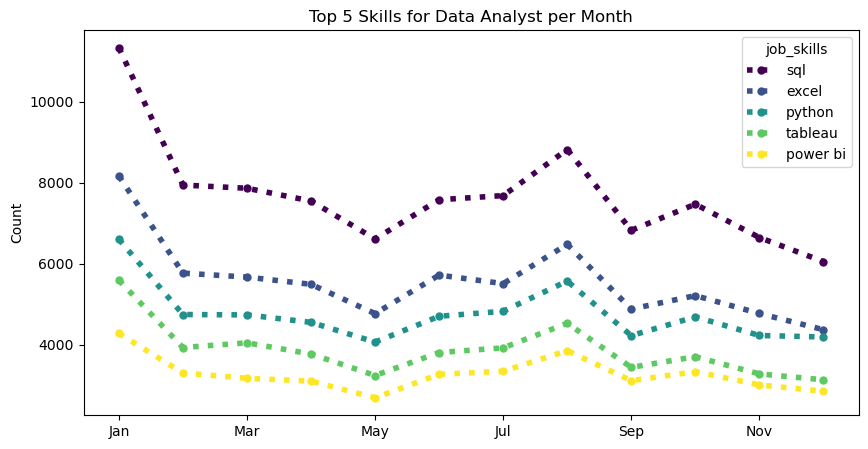

In [23]:
# new chart 
df_da_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', #options: '-'. '--'. '-.', ':'
    colormap='viridis', #options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    markersize=5,
    marker='o', #options = 'o', 'x', '+', '*', '5', ',', '.', '1', '2', '4', ....
    figsize=(10,5)  
)
plt.title('Top 5 Skills for Data Analyst per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [25]:
# explode the skills job into individual rows
df_exploded = df_da.explode('job_skills')

# calculate the avarage and count of job postings per skill 
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)

# limit the top 20 skills
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


In [ ]:
# install dulu di terminal 
# pip install adjustText 

from adjustText import adjust_text

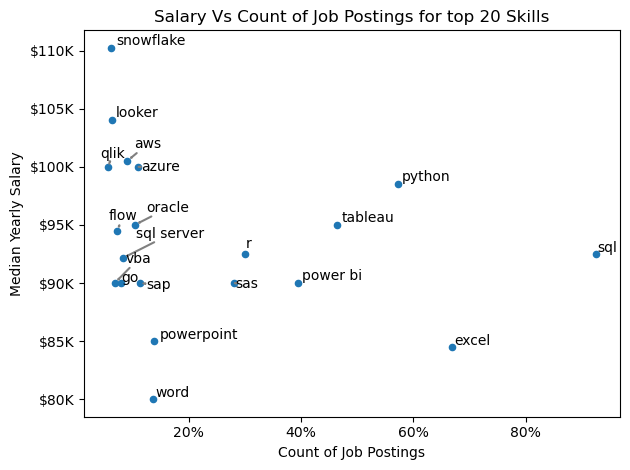

In [ ]:
# state subplots to get the ax for accesing the set major formater  
# fig, ax = plt.subplots()

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []

for i, txt in enumerate (skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=1.5))

# format the y label into currency and x label into percentage
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda X, pos: f'{int(X/1000)}%'))

# set axis labels, title and legend 
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary Vs Count of Job Postings for top {skill_count} Skills')

# adjust layout and display the plot 
plt.tight_layout()
plt.show()

